# Plots for E3SMv3 XLE overview paper using the piControl experiments

author: Bryce Harrop



In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import os
os.environ['PROJ_LIB'] = r'/global/homes/b/beharrop/.conda/envs/myenv2/share/proj/'
import re
import pyproj
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import metpy
import datetime
import cartopy.crs as ccrs
import cartopy.feature as cf
from functools import partial
import xesmf as xe
import gc
import warnings
import cftime
from scipy import stats
import seaborn as sns
import glob
import yaml
from pathlib import Path
from itertools import combinations
import xcdat
import xclim

# Isphaera imports
%load_ext autoreload
%autoreload 2
import importlib
from isphaera import fusion as ispf
from isphaera import signal as isps
from isphaera import visual as ispv
%reload_ext autoreload

warnings.filterwarnings('ignore')

#### Remaking Fig. 4 from E3SMv2 overview

Atmospheric output are available under the following locations
 - `/global/cfs/cdirs/e3smdata/simulations/v3.LR.piControl/post/atm/glb/ts/monthly/10yr/{variable}_{YYYY}01_{YYYY}12.nc`
 - `/global/cfs/cdirs/e3smdata/simulations/v3.LR.highECS.piControl/post/atm/glb/ts/monthly/10yr/{variable}_{YYYY}01_{YYYY}12.nc`
 - `/global/cfs/cdirs/e3smdata/simulations/v3.LR.lowECS.piControl/post/atm/glb/ts/monthly/10yr/{variable}_{YYYY}01_{YYYY}12.nc`
 
 To construct TOA net flux, we need `FSNTOA` and `FLUT`.  2m air temperature is stored in `TREFHT`.

 Sea-ice data requires the isphaera package (https://github.com/Arctic-InteRFACE/Isphaera) and will be processed elsewhere before being added here.

 MOC ...

In [10]:

sims = {
    'ctrl': 'v3.LR.piControl',
    'high': 'v3.LR.highECS.piControl',
    'low':  'v3.LR.lowECS.piControl',
}

base_dir = '/global/cfs/cdirs/e3smdata/simulations/{sim}/post/atm/glb/ts/monthly/10yr'
variables = ['FSNTOA', 'FLUT', 'TREFHT']

def load_atm_data(sim_name):
    path = base_dir.format(sim=sim_name)
    var_ds_list = []
    for var in variables:
        files = sorted(glob.glob(f'{path}/{var}_*.nc'))
        ds = xr.open_mfdataset(files, combine='by_coords', use_cftime=True, parallel=True)
        var_ds_list.append(ds[[var]])
    return xr.merge(var_ds_list)

ds_ctrl = load_atm_data(sims['ctrl'])
ds_high = load_atm_data(sims['high'])
ds_low  = load_atm_data(sims['low'])

moc_path = '/global/cfs/cdirs/e3smdata/simulations/{sim}/post/analysis/mpas_analysis/ts_0001-0500_climo_0451-0500/timeseries/moc/mocTimeSeries_0001-0500.nc'

def load_moc_data(sim_name):
    path = moc_path.format(sim=sim_name)
    ds = xr.open_dataset(path, use_cftime=True)
    return ds[['mocAtlantic26']]

moc_ctrl = load_moc_data(sims['ctrl'])
moc_high = load_moc_data(sims['high'])
moc_low  = load_moc_data(sims['low'])


In [11]:
def add_time_bnds(ds):
    """
    Add a time_bnds variable to a dataset whose time coordinate represents
    the right bound of each monthly interval (i.e., first day of the following
    month).  The left bound is set to the first day of the current month at
    00:00:00, matching the E3SM convention.
    """
    times = ds["time"].values

    def left_bound(dt):
        year, month = dt.year, dt.month - 1
        if month == 0:
            month, year = 12, year - 1
        return type(dt)(year, month, 1, 0, 0, 0, 0, has_year_zero=dt.has_year_zero)

    left_bnds  = np.array([left_bound(t) for t in times])
    right_bnds = times

    time_bnds = xr.DataArray(
        np.array(list(zip(left_bnds, right_bnds))),
        dims=["time", "bnds"],
        coords={"time": ds["time"]},
    )
    ds = ds.assign({"time_bnds": time_bnds})
    ds["time"].attrs["bounds"] = "time_bnds"
    return ds

ds_ctrl = xcdat.center_times(add_time_bnds(ds_ctrl))
ds_high = xcdat.center_times(add_time_bnds(ds_high))
ds_low  = xcdat.center_times(add_time_bnds(ds_low))


In [39]:
31/365

0.08493150684931507

In [ ]:
# Compute net TOA flux
ds_ctrl['net_TOA'] = ds_ctrl['FSNTOA'] - ds_ctrl['FLUT']
ds_high['net_TOA'] = ds_high['FSNTOA'] - ds_high['FLUT']
ds_low['net_TOA']  = ds_low ['FSNTOA'] - ds_low ['FLUT']

sims_map = {
    'ctrl': (ds_ctrl, moc_ctrl),
    'high': (ds_high, moc_high),
    'low':  (ds_low,  moc_low ),
}

# Annual means
net_TOA_ann = {k: ds ['net_TOA'      ].groupby('time.year').mean('time').compute() for k, (ds,  _  ) in sims_map.items()}
TREFHT_ann  = {k: ds ['TREFHT'       ].groupby('time.year').mean('time').compute() for k, (ds,  _  ) in sims_map.items()}
moc_ann     = {k: moc['mocAtlantic26'].groupby('Time.year').mean('Time').compute() for k, (_,   moc) in sims_map.items()}

# 12-month running means (centered, NaN at edges)
net_TOA_rm = {k: ds ['net_TOA'      ].rolling(time=12, center=True).mean().compute() for k, (ds,  _  ) in sims_map.items()}
TREFHT_rm  = {k: ds ['TREFHT'       ].rolling(time=12, center=True).mean().compute() for k, (ds,  _  ) in sims_map.items()}
moc_rm     = {k: moc['mocAtlantic26'].rolling(Time=12, center=True).mean().compute() for k, (_,   moc) in sims_map.items()}

# Convert cftime coordinate to fractional simulation year (year + (doy-1)/365)
def to_year_frac(da, dim='time'):
    times = da[dim].values
    year_frac = np.array([t.year + (t.timetuple().tm_yday - 1) / 365 for t in times])
    return da.assign_coords({dim: year_frac})

net_TOA_rm = {k: to_year_frac(da)             for k, da in net_TOA_rm.items()}
TREFHT_rm  = {k: to_year_frac(da)             for k, da in TREFHT_rm.items()}
moc_rm     = {k: to_year_frac(da, dim='Time') for k, da in moc_rm.items()}


In [48]:
colors     = sns.color_palette('tab10', n_colors=3)
linewidth  = 2
alpha      = 1
fontsize   = 14
plot_deets = dict(
    ctrl=dict(color=colors[2], label='Default',  linewidth=linewidth, alpha=alpha),
    high=dict(color=colors[1], label='High ECS', linewidth=linewidth, alpha=alpha),
    low =dict(color=colors[0], label='Low ECS',  linewidth=linewidth, alpha=alpha),
)

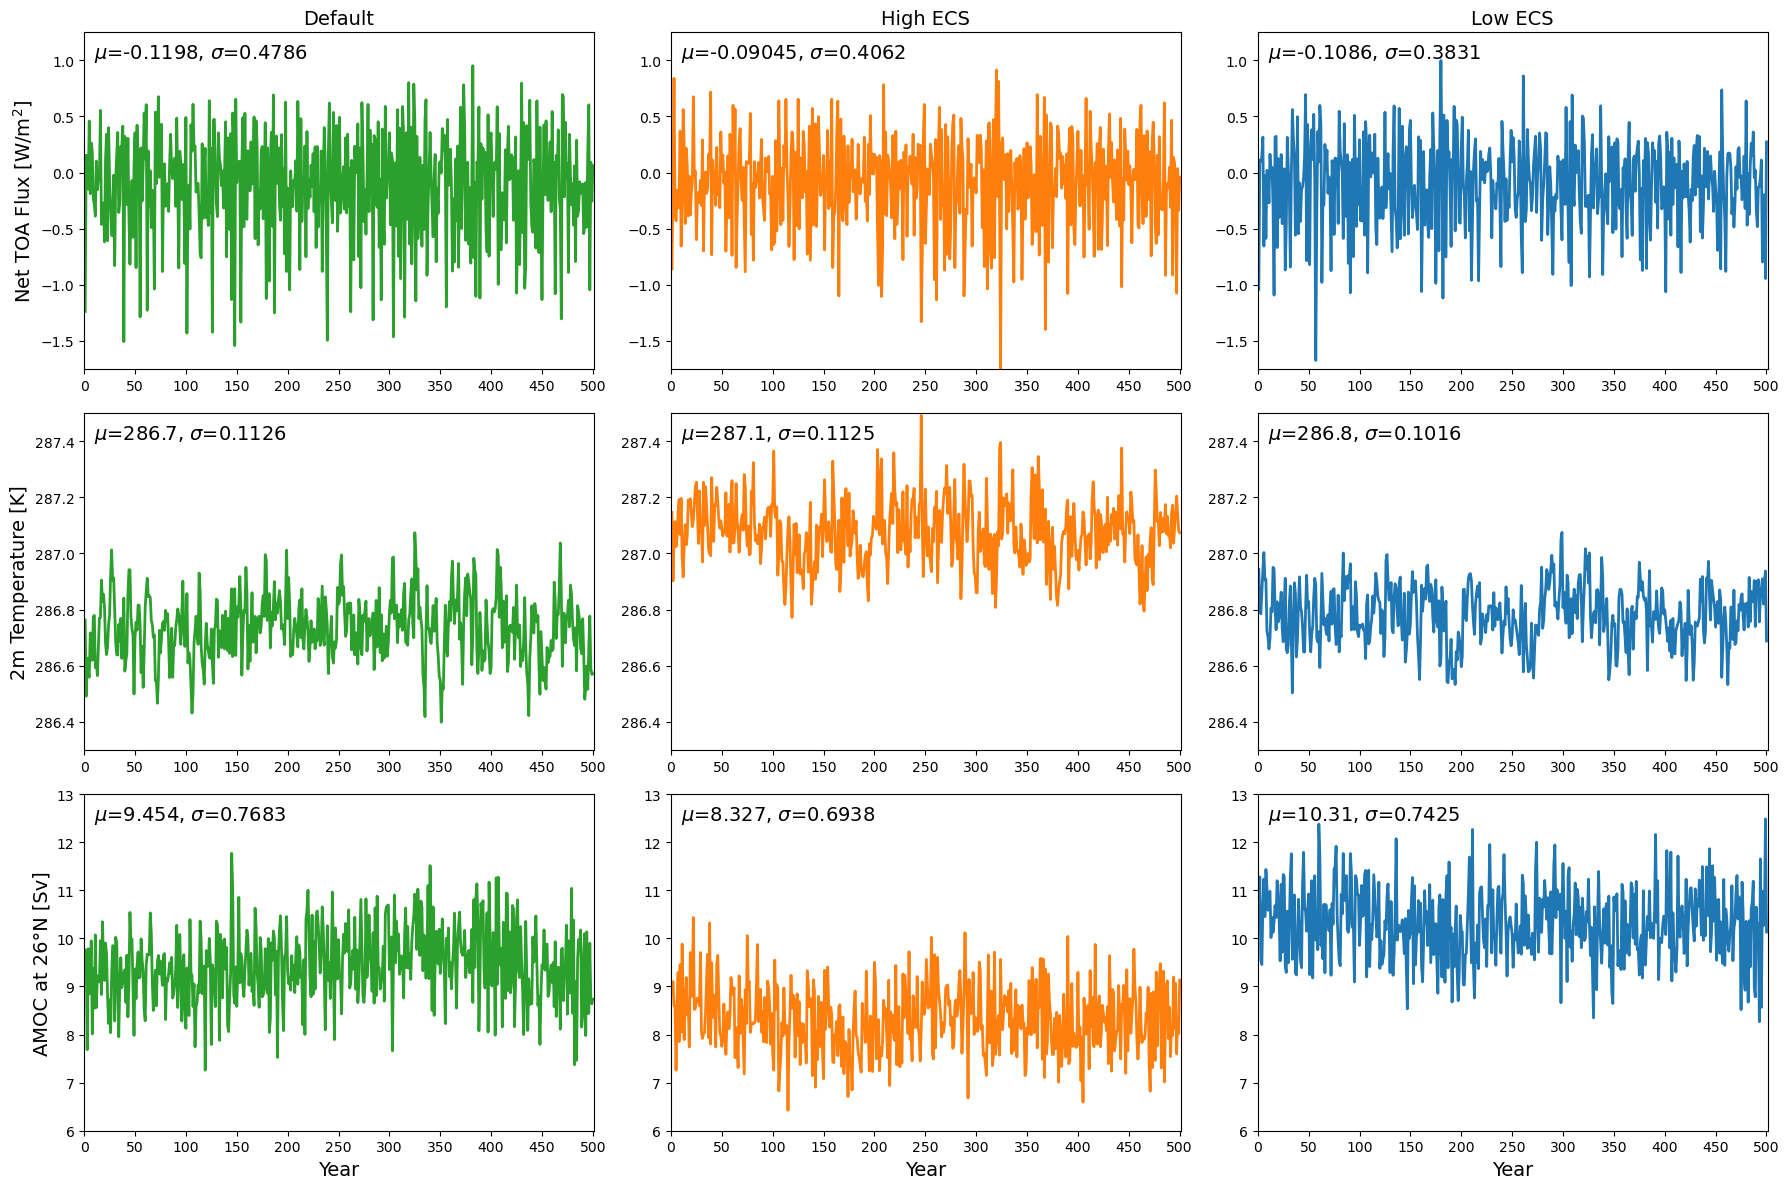

In [53]:

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))

sims_order = ['ctrl', 'high', 'low']
atm_rows = [
    ('net_TOA', 'Net TOA Flux',   'W/m$^2$', [-1.75, 1.25],  [net_TOA_ann['ctrl'],  net_TOA_ann['high'],  net_TOA_ann['low'] ]),
    ('TREFHT',  '2m Temperature', 'K',       [286.3, 287.5], [TREFHT_ann['ctrl'],  TREFHT_ann['high'],  TREFHT_ann['low'] ]),
]
moc_datasets = [moc_ann['ctrl'], moc_ann['high'], moc_ann['low']]

# ATM rows (rows 0 and 1)
for row, (var, row_title, ylabel, ylims, dsets) in enumerate(atm_rows):
    for col, (sim_key, ds) in enumerate(zip(sims_order, dsets)):
        ax = axs[row, col]
        data = ds.isel(rgn=0)
        data.plot(ax=ax, **plot_deets[sim_key])
        mean_val = float(data.mean())
        std_val  = float(data.std())
        ax.text(0.02, 0.97,
                f'$\mu$={mean_val:.4g}, $\sigma$={std_val:.4g}',
                transform=ax.transAxes, ha='left', va='top',
                fontsize=fontsize, clip_on=False)
        ax.set_title(plot_deets[sim_key]['label'] if row == 0 else '', fontsize=fontsize)
        ax.set_ylabel(f'{row_title} [{ylabel}]' if col == 0 else '', fontsize=fontsize)
        ax.set_xlabel('', fontsize=fontsize)
        ax.set_xticks(np.arange(0, 501, 50))
        ax.set_xlim(0, 501)
        ax.set_ylim(ylims)

# MOC row (row 2)
for col, (sim_key, moc_ds) in enumerate(zip(sims_order, moc_datasets)):
    ax = axs[2, col]
    data = moc_ds#['mocAtlantic26']
    data.plot(ax=ax, **plot_deets[sim_key])
    mean_val = float(data.mean())
    std_val  = float(data.std())
    ax.text(0.02, 0.97,
            f'$\mu$={mean_val:.4g}, $\sigma$={std_val:.4g}',
            transform=ax.transAxes, ha='left', va='top',
            fontsize=fontsize, clip_on=False)
    ax.set_title('', fontsize=fontsize)
    ax.set_ylabel('AMOC at 26°N [Sv]' if col == 0 else '', fontsize=fontsize)
    ax.set_xlabel('Year', fontsize=fontsize)
    ax.set_xticks(np.arange(0, 501, 50))
    ax.set_xlim(0, 501)
    ax.set_ylim(6, 13)

fig.tight_layout()


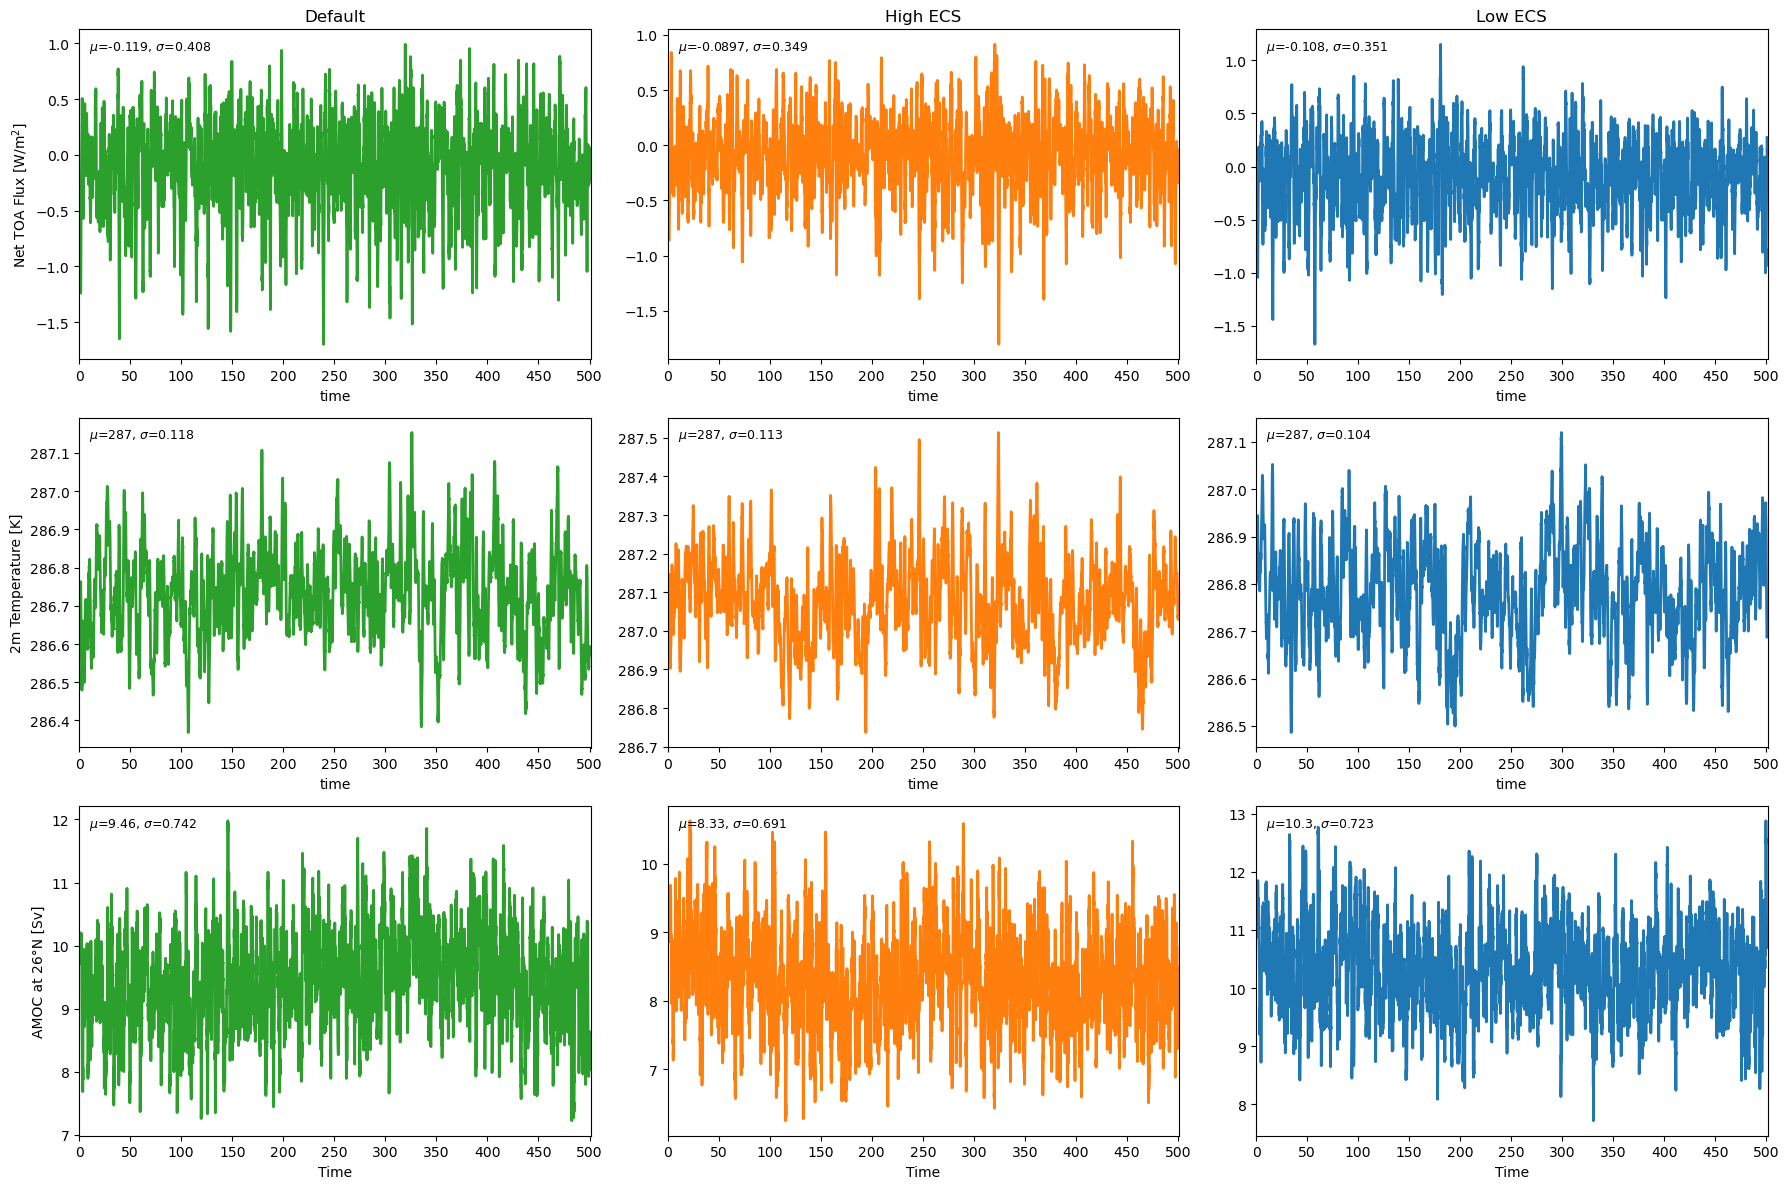

In [ ]:

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))

sims_order = ['ctrl', 'high', 'low']
atm_rows = [
    ('net_TOA', 'Net TOA Flux',   'W/m$^2$',  [net_TOA_rm['ctrl'],  net_TOA_rm['high'],  net_TOA_rm['low'] ]),
    ('TREFHT',  '2m Temperature', 'K',        [TREFHT_rm['ctrl'],  TREFHT_rm['high'],  TREFHT_rm['low'] ]),
]
moc_datasets = [moc_rm['ctrl'], moc_rm['high'], moc_rm['low']]

# ATM rows (rows 0 and 1)
for row, (var, row_title, ylabel, dsets) in enumerate(atm_rows):
    for col, (sim_key, ds) in enumerate(zip(sims_order, dsets)):
        ax = axs[row, col]
        data = ds.isel(rgn=0)
        data.plot(ax=ax, **plot_deets[sim_key])
        mean_val = float(data.mean())
        std_val  = float(data.std())
        ax.text(0.02, 0.97,
                f'$\mu$={mean_val:.3g}, $\sigma$={std_val:.3g}',
                transform=ax.transAxes, ha='left', va='top',
                fontsize=fontsize, clip_on=False)
        ax.set_title(plot_deets[sim_key]['label'] if row == 0 else '')
        ax.set_ylabel(f'{row_title} [{ylabel}]' if col == 0 else '')
        ax.set_xticks(np.arange(0, 501, 50))
        ax.set_xlim(0, 501)

# MOC row (row 2)
for col, (sim_key, moc_ds) in enumerate(zip(sims_order, moc_datasets)):
    ax = axs[2, col]
    data = moc_ds#['mocAtlantic26']
    data.plot(ax=ax, **plot_deets[sim_key])
    mean_val = float(data.mean())
    std_val  = float(data.std())
    ax.text(0.02, 0.97,
            f'$\mu$={mean_val:.3g}, $\sigma$={std_val:.3g}',
            transform=ax.transAxes, ha='left', va='top',
            fontsize=fontsize, clip_on=False)
    ax.set_title('')
    ax.set_ylabel('AMOC at 26°N [Sv]' if col == 0 else '')
    ax.set_xticks(np.arange(0, 501, 50))
    ax.set_xlim(0, 501)

fig.tight_layout()
